In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time
from sklearn.cluster import kmeans_plusplus


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Utilisant device: {DEVICE}")


class Autoencoder(nn.Module):
    """Autoencoder pour compression et extraction de l'espace latent"""
    
    def __init__(self, input_dim: int, latent_dim: int = 3):
        super(Autoencoder, self).__init__()
        
        # ENCODEUR: Réduit la dimension
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            # GOULOT D'ÉTRANGLEMENT (bottleneck)
            nn.Linear(32, latent_dim)  # ← Espace latent
        )
        
        # DÉCODEUR: Reconstruit les données
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, input_dim)
        )
    
    def encode(self, x):
        """Retourne les points dans l'espace latent"""
        return self.encoder(x)
    
    def decode(self, z):
        """Reconstruit à partir de l'espace latent"""
        return self.decoder(z)
    
    def forward(self, x):
        """Forward pass complet"""
        z = self.encode(x)
        x_reconstructed = self.decode(z)
        return x_reconstructed, z

[v0] Utilisant device: cpu


In [ ]:

def train_autoencoder(X: np.ndarray, latent_dim: int = 3, 
                     epochs: int = 100, batch_size: int = 32,
                     verbose: bool = True) -> Autoencoder:
    """
    Entraîne l'autoencoder sur les données numériques
    
    Args:
        X: Données numériques (n_samples, n_features)
        latent_dim: Dimension de l'espace latent
        epochs: Nombre d'epochs
        batch_size: Taille du batch
        verbose: Afficher la progression
    
    Returns:
        Autoencoder entraîné
    """
    
    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Convertir en tensor PyTorch
    X_tensor = torch.FloatTensor(X_scaled).to(DEVICE)
    
    # Créer le modèle
    model = Autoencoder(X.shape[1], latent_dim).to(DEVICE)
    
    # Optimizer et loss
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    # Entraînement
    if verbose:
        print(f"\nEntraînement autoencoder:")
        print(f"     Input: {X.shape[1]} features → Latent: {latent_dim} dims")
    
    losses = []
    for epoch in range(epochs):
        # Mini-batches
        indices = np.random.permutation(len(X_tensor))
        epoch_loss = 0
        
        for i in range(0, len(X_tensor), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_tensor[batch_idx]
            
            # Forward pass
            X_reconstructed, _ = model(X_batch)
            loss = criterion(X_reconstructed, X_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        epoch_loss /= (len(X_tensor) // batch_size)
        losses.append(epoch_loss)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"     Epoch {epoch+1:3d}/{epochs}: Loss = {epoch_loss:.6f}")
    
    model.eval()
    return model, scaler, losses

In [ ]:
def predict_centroids_with_autoencoder(X: np.ndarray, n_clusters: int,
                                       model: Autoencoder, scaler,
                                       latent_dim: int = 3) -> np.ndarray:
    """
    Prédire les centroïdes en utilisant l'espace latent
    
    Processus:
    1. Standardiser X avec le même scaler
    2. Encoder X → obtenir Z (espace latent)
    3. K-means sur Z → trouver centroïdes_latent
    4. Retourner centroïdes_latent
    
    Args:
        X: Données numériques
        n_clusters: Nombre de clusters
        model: Autoencoder entraîné
        scaler: StandardScaler utilisé pour l'entraînement
        latent_dim: Dimension de l'espace latent
    
    Returns:
        Centroïdes dans l'espace latent
    """
    
    # Étape A: Standardiser et encoder
    X_scaled = scaler.transform(X)
    X_tensor = torch.FloatTensor(X_scaled).to(DEVICE)
    
    with torch.no_grad():
        Z = model.encode(X_tensor).cpu().numpy()
    
    print(f"\n Espace latent:")
    print(f"     Forme: {Z.shape}")
    print(f"     Densité: {Z.shape[0]} points dans {latent_dim}D")
    
    # Étape B: K-means dans l'espace latent
    kmeans_latent = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    kmeans_latent.fit(Z)
    
    centroid_latent = kmeans_latent.cluster_centers_
    
    print(f"\n[v0] Centroïdes trouvés dans l'espace latent:")
    print(f"     Forme: {centroid_latent.shape}")
    print(f"     Inertie latent: {kmeans_latent.inertia_:.2f}")
    
    return centroid_latent, Z


In [33]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.datasets import load_iris

In [ ]:
def trace_kmeans_convergence(X: np.ndarray, n_clusters: int, init_method: str = "random",
                             random_state: int = 42, max_iter: int = 100, tol: float = 1e-4):
    """
    Suit l'évolution de l'inertie de KMeans itération par itération.

    Parameters
    ----------
    X : np.ndarray
        Données d'entrée
    n_clusters : int
        Nombre de clusters
    init_method : str
        'random' ou 'k-means++'
    random_state : int
        Seed
    max_iter : int
        Nombre max d'itérations
    tol : float
        Tolérance d'arrêt

    Returns
    -------
    centroids : np.ndarray
        Centroïdes finaux
    labels : np.ndarray
        Labels finaux
    inertia_history : list
        Historique de l'inertie à chaque itération
    """
    rng = np.random.RandomState(random_state)

    # Initialisation
    if init_method == "random":
        init_idx = rng.choice(X.shape[0], size=n_clusters, replace=False)
        centroids = X[init_idx].copy()
    elif init_method == "k-means++":
        centroids, _ = kmeans_plusplus(X, n_clusters=n_clusters, random_state=random_state)
    else:
        raise ValueError("init_method doit être 'random' ou 'k-means++'")

    inertia_history = []

    for _ in range(max_iter):
        # Distances point-centroïdes
        distances = cdist(X, centroids, metric="euclidean")

        # Assignation
        labels = np.argmin(distances, axis=1)

        # Inertie
        inertia = np.sum((X - centroids[labels]) ** 2)
        inertia_history.append(inertia)

        # Mise à jour des centroïdes
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
            for k in range(n_clusters)
        ])

        # Critère d'arrêt
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if shift < tol:
            break

    return centroids, labels, inertia_history

In [ ]:
def compare_methods(X: np.ndarray, n_clusters: int) -> dict:
    """
    Comparer:
    1. K-means Random
    2. K-means++
    3. Autoencoder + K-means
    """
    
    print("\n" + "="*80)
    print("COMPARAISON: Random vs K-means++ vs Autoencoder+KMeans")
    print("="*80)
    
    results = {}

    # =========================
    # 1) K-means Random
    # =========================
    print("\n[1] K-means Random:")
    start = time.perf_counter()

    kmeans_random = KMeans(
        n_clusters=n_clusters,
        init='random',
        n_init=1,
        random_state=42
    )
    labels_random = kmeans_random.fit_predict(X)
    elapsed_random = time.perf_counter() - start

    sil_random = silhouette_score(X, labels_random)
    dbi_random = davies_bouldin_score(X, labels_random)

    # courbe de convergence
    _, _, inertia_history_random = trace_kmeans_convergence(
        X, n_clusters=n_clusters, init_method="random", random_state=42
    )

    results['Random'] = {
        'inertia': kmeans_random.inertia_,
        'silhouette': sil_random,
        'davies_bouldin': dbi_random,
        'centroids': kmeans_random.cluster_centers_,
        'labels': labels_random,
        'time_sec': elapsed_random,
        'convergence': inertia_history_random
    }

    print(f"     Inertia: {kmeans_random.inertia_:.2f}")
    print(f"     Silhouette: {sil_random:.4f}")
    print(f"     Davies-Bouldin: {dbi_random:.4f}")
    print(f"     Temps: {elapsed_random:.4f} sec")

    # =========================
    # 2) K-means++
    # =========================
    print("\n[2] K-means++:")
    start = time.perf_counter()

    kmeans_pp = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    labels_pp = kmeans_pp.fit_predict(X)
    elapsed_pp = time.perf_counter() - start

    sil_pp = silhouette_score(X, labels_pp)
    dbi_pp = davies_bouldin_score(X, labels_pp)

    # courbe de convergence
    _, _, inertia_history_pp = trace_kmeans_convergence(
        X, n_clusters=n_clusters, init_method="k-means++", random_state=42
    )

    results['K-means++'] = {
        'inertia': kmeans_pp.inertia_,
        'silhouette': sil_pp,
        'davies_bouldin': dbi_pp,
        'centroids': kmeans_pp.cluster_centers_,
        'labels': labels_pp,
        'time_sec': elapsed_pp,
        'convergence': inertia_history_pp
    }

    print(f"     Inertia: {kmeans_pp.inertia_:.2f}")
    print(f"     Silhouette: {sil_pp:.4f}")
    print(f"     Davies-Bouldin: {dbi_pp:.4f}")
    print(f"     Temps: {elapsed_pp:.4f} sec")

    # =========================
    # 3) Autoencoder + K-means
    # =========================
    print("\n[3] Autoencoder + K-means:")
    start_total = time.perf_counter()

    latent_dim = min(3, X.shape[1] - 1)

    start_ae = time.perf_counter()
    model, scaler, losses = train_autoencoder(X, latent_dim=latent_dim, epochs=100)
    ae_train_time = time.perf_counter() - start_ae

    centroid_latent, Z = predict_centroids_with_autoencoder(
        X, n_clusters, model, scaler, latent_dim
    )

    start_latent_kmeans = time.perf_counter()
    kmeans_ae = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    labels_ae = kmeans_ae.fit_predict(Z)
    latent_kmeans_time = time.perf_counter() - start_latent_kmeans

    total_ae_time = time.perf_counter() - start_total

    inertia_ae = np.sum(np.min(cdist(Z, kmeans_ae.cluster_centers_)**2, axis=1))
    sil_ae = silhouette_score(Z, labels_ae)
    dbi_ae = davies_bouldin_score(Z, labels_ae)

    results['Autoencoder'] = {
        'inertia': inertia_ae,
        'silhouette': sil_ae,
        'davies_bouldin': dbi_ae,
        'centroids': kmeans_ae.cluster_centers_,
        'labels': labels_ae,
        'model': model,
        'scaler': scaler,
        'Z': Z,
        'ae_losses': losses,
        'time_sec': total_ae_time,
        'ae_train_time_sec': ae_train_time,
        'latent_kmeans_time_sec': latent_kmeans_time
    }

    print(f"     Inertia: {inertia_ae:.2f}")
    print(f"     Silhouette: {sil_ae:.4f}")
    print(f"     Davies-Bouldin: {dbi_ae:.4f}")
    print(f"     Temps total: {total_ae_time:.4f} sec")
    print(f"       - Entraînement AE: {ae_train_time:.4f} sec")
    print(f"       - KMeans sur Z:    {latent_kmeans_time:.4f} sec")

    # =========================
    # Résumé
    # =========================
    print("\n" + "="*80)
    print("RÉSUMÉ:")
    print("="*80)

    for method, metrics in results.items():
        print(f"\n{method}:")
        print(f"  Inertia:        {metrics['inertia']:10.2f}")
        print(f"  Silhouette:     {metrics['silhouette']:10.4f}")
        print(f"  Davies-Bouldin: {metrics['davies_bouldin']:10.4f}")
        print(f"  Temps (sec):    {metrics['time_sec']:10.4f}")

    return results, results['Autoencoder'].get('Z', None)


import numpy as np
import matplotlib.pyplot as plt

def visualize_results(X: np.ndarray, results: dict, Z: np.ndarray = None,
                      save_path: str = "autoencoder_comparison.png"):
    """Créer des visualisations comparatives entre plusieurs méthodes de clustering.

    Paramètres
    ----------
    X : np.ndarray
        Données originales, shape (n_samples, n_features)
    results : dict
        Dictionnaire contenant pour chaque méthode :
        - 'centroids': centres des clusters
        - 'inertia': inertie
        - optionnellement 'labels': labels des clusters
    Z : np.ndarray, optional
        Représentation latente issue de l'autoencoder, shape (n_samples, latent_dim)
    save_path : str
        Chemin de sauvegarde de la figure
    """

    if X.ndim != 2:
        raise ValueError("X doit être un tableau 2D de forme (n_samples, n_features).")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Comparaison: K-means vs K-means++ vs Autoencoder", fontsize=16)

    methods = ["Random", "K-means++", "Autoencoder"]
    colors = ["red", "blue", "green"]

    for ax, method, color in zip(axes.flat[:3], methods, colors):
        if method not in results:
            ax.set_visible(False)
            continue

        if "centroids" not in results[method]:
            ax.set_visible(False)
            continue

        centroids = results[method]["centroids"]
        labels = results[method].get("labels", None)
        inertia = results[method].get("inertia", None)

        # Choisir le bon espace
        if method == "Autoencoder":
            if Z is None:
                ax.set_visible(False)
                continue
            data = Z
        else:
            data = X

        # Vérification de cohérence dimensionnelle
        if data.shape[1] != centroids.shape[1]:
            ax.set_title(f"{method}\nDimensions incompatibles")
            ax.axis("off")
            continue

        # Cas 2D direct
        if data.shape[1] == 2:
            if labels is not None:
                ax.scatter(data[:, 0], data[:, 1], c=labels, cmap="tab10", alpha=0.6, s=20)
            else:
                ax.scatter(data[:, 0], data[:, 1], alpha=0.5, s=20)

            ax.scatter(
                centroids[:, 0], centroids[:, 1],
                c=color, marker="*", s=500,
                edgecolors="black", linewidth=2
            )

            title = method
            if inertia is not None:
                title += f"\nInertia: {inertia:.2f}"
            ax.set_title(title)
            ax.set_xlabel("Dim 1")
            ax.set_ylabel("Dim 2")

        else:
            from sklearn.decomposition import PCA

            pca = PCA(n_components=2)
            data_2d = pca.fit_transform(data)
            centroids_2d = pca.transform(centroids)

            if labels is not None:
                ax.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap="tab10", alpha=0.6, s=20)
            else:
                ax.scatter(data_2d[:, 0], data_2d[:, 1], alpha=0.5, s=20)

            ax.scatter(
                centroids_2d[:, 0], centroids_2d[:, 1],
                c=color, marker="*", s=500,
                edgecolors="black", linewidth=2
            )

            title = method
            if inertia is not None:
                title += f"\nInertia: {inertia:.2f}"
            ax.set_title(title)
            ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

        ax.grid(True, alpha=0.3)

    # === 4e subplot : espace latent autoencoder ===
    ax = axes.flat[3]

    if Z is not None:
        labels_ae = results.get("Autoencoder", {}).get("labels", None)
        centroid_latent = results.get("Autoencoder", {}).get("centroids", None)

        if Z.shape[1] == 2:
            if labels_ae is not None:
                ax.scatter(Z[:, 0], Z[:, 1], c=labels_ae, cmap="tab10", alpha=0.6, s=20)
            else:
                ax.scatter(Z[:, 0], Z[:, 1], alpha=0.5, s=20)

            if centroid_latent is not None and centroid_latent.shape[1] == 2:
                ax.scatter(
                    centroid_latent[:, 0], centroid_latent[:, 1],
                    c="green", marker="*", s=500,
                    edgecolors="black", linewidth=2
                )

            ax.set_xlabel("Latent Dim 1")
            ax.set_ylabel("Latent Dim 2")
            ax.set_title("Espace Latent (Autoencoder)")

        elif Z.shape[1] > 2:
            from sklearn.decomposition import PCA

            pca_latent = PCA(n_components=2)
            Z_2d = pca_latent.fit_transform(Z)

            if labels_ae is not None:
                ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels_ae, cmap="tab10", alpha=0.6, s=20)
            else:
                ax.scatter(Z_2d[:, 0], Z_2d[:, 1], alpha=0.5, s=20)

            if centroid_latent is not None and centroid_latent.shape[1] == Z.shape[1]:
                centroid_latent_2d = pca_latent.transform(centroid_latent)
                ax.scatter(
                    centroid_latent_2d[:, 0], centroid_latent_2d[:, 1],
                    c="green", marker="*", s=500,
                    edgecolors="black", linewidth=2
                )

            ax.set_xlabel(f"PC1 ({pca_latent.explained_variance_ratio_[0]:.1%})")
            ax.set_ylabel(f"PC2 ({pca_latent.explained_variance_ratio_[1]:.1%})")
            ax.set_title("Espace Latent (Autoencoder)")
        else:
            ax.text(0.5, 0.5, "Espace latent < 2D", ha="center", va="center")
            ax.set_title("Espace Latent (Autoencoder)")
            ax.axis("off")
    else:
        ax.text(0.5, 0.5, "Z non fourni", ha="center", va="center")
        ax.set_title("Espace Latent (Autoencoder)")
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nGraphique sauvegardé : {save_path}")
    plt.show()



In [ ]:
def plot_convergence_and_times(results: dict, save_path: str = "convergence_and_times.png"):
    """
    Affiche :
    - courbes de convergence de Random et K-means++
    - temps d'exécution des approches
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # =========================
    # Graphe de convergence
    # =========================
    ax = axes[0]

    if 'Random' in results and 'convergence' in results['Random']:
        ax.plot(
            range(1, len(results['Random']['convergence']) + 1),
            results['Random']['convergence'],
            marker='o',
            label='K-means Random'
        )

    if 'K-means++' in results and 'convergence' in results['K-means++']:
        ax.plot(
            range(1, len(results['K-means++']['convergence']) + 1),
            results['K-means++']['convergence'],
            marker='s',
            label='K-means++'
        )

    ax.set_title("Convergence de l'inertie")
    ax.set_xlabel("Itération")
    ax.set_ylabel("Inertie")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # =========================
    # Temps d'exécution
    # =========================
    ax = axes[1]

    methods = []
    times = []

    for method in ['Random', 'K-means++', 'Autoencoder']:
        if method in results and 'time_sec' in results[method]:
            methods.append(method)
            times.append(results[method]['time_sec'])

    bars = ax.bar(methods, times)
    ax.set_title("Temps d'exécution par approche")
    ax.set_ylabel("Temps (secondes)")
    ax.grid(True, axis='y', alpha=0.3)

    for bar, t in zip(bars, times):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{t:.4f}s",
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nGraphique convergence/temps sauvegardé : {save_path}")
    plt.show()

[v0] Deep Embedded Clustering Demo

[TEST 1] Données synthétiques (300 points, 4 clusters)

COMPARAISON: Random vs K-means++ vs Autoencoder+KMeans

[1] K-means Random (baseline mauvais):
     Inertia: 16963.35
     Silhouette: 0.5256
     Davies-Bouldin: 1.6291

[2] K-means++ (baseline bon):
     Inertia: 1858.20
     Silhouette: 0.8097
     Davies-Bouldin: 0.2719

[3] Autoencoder + K-means (NOUVEAU):

[v0] Entraînement autoencoder:
     Input: 10 features → Latent: 3 dims
     Epoch  20/100: Loss = 0.084309
     Epoch  40/100: Loss = 0.071799
     Epoch  60/100: Loss = 0.065570
     Epoch  80/100: Loss = 0.059497
     Epoch 100/100: Loss = 0.056191

[v0] Espace latent:
     Forme: (300, 3)
     Densité: 300 points dans 3D

[v0] Centroïdes trouvés dans l'espace latent:
     Forme: (4, 3)
     Inertie latent: 94.12
     Inertia: 94.12
     Silhouette: 0.7557
     Davies-Bouldin: 0.3403

RÉSUMÉ:

Random:
  Inertia:        16963.35
  Silhouette:       0.5256
  Davies-Bouldin:   1.6291

K-

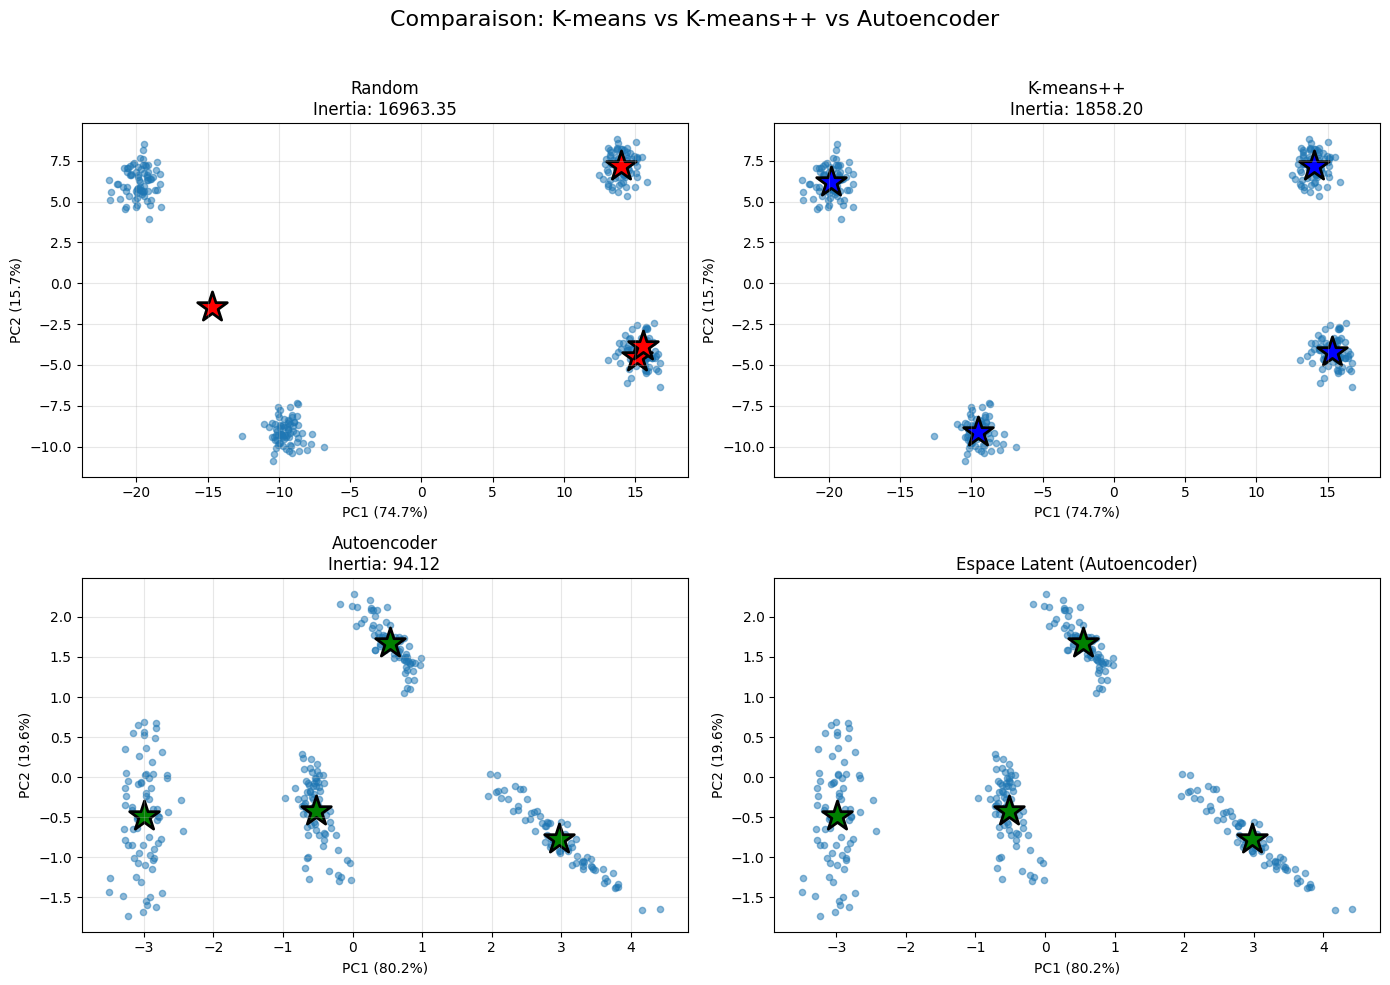



[TEST 2] Iris Dataset (150 points, 4 features, 3 clusters)

COMPARAISON: Random vs K-means++ vs Autoencoder+KMeans

[1] K-means Random (baseline mauvais):
     Inertia: 78.85
     Silhouette: 0.5528
     Davies-Bouldin: 0.6620

[2] K-means++ (baseline bon):
     Inertia: 78.85
     Silhouette: 0.5528
     Davies-Bouldin: 0.6620

[3] Autoencoder + K-means (NOUVEAU):

[v0] Entraînement autoencoder:
     Input: 4 features → Latent: 3 dims
     Epoch  20/100: Loss = 0.310549
     Epoch  40/100: Loss = 0.137266
     Epoch  60/100: Loss = 0.123626
     Epoch  80/100: Loss = 0.110760
     Epoch 100/100: Loss = 0.097066

[v0] Espace latent:
     Forme: (150, 3)
     Densité: 150 points dans 3D

[v0] Centroïdes trouvés dans l'espace latent:
     Forme: (3, 3)
     Inertie latent: 163.21
     Inertia: 163.33
     Silhouette: 0.4319
     Davies-Bouldin: 0.8669

RÉSUMÉ:

Random:
  Inertia:           78.85
  Silhouette:       0.5528
  Davies-Bouldin:   0.6620

K-means++:
  Inertia:           78.8

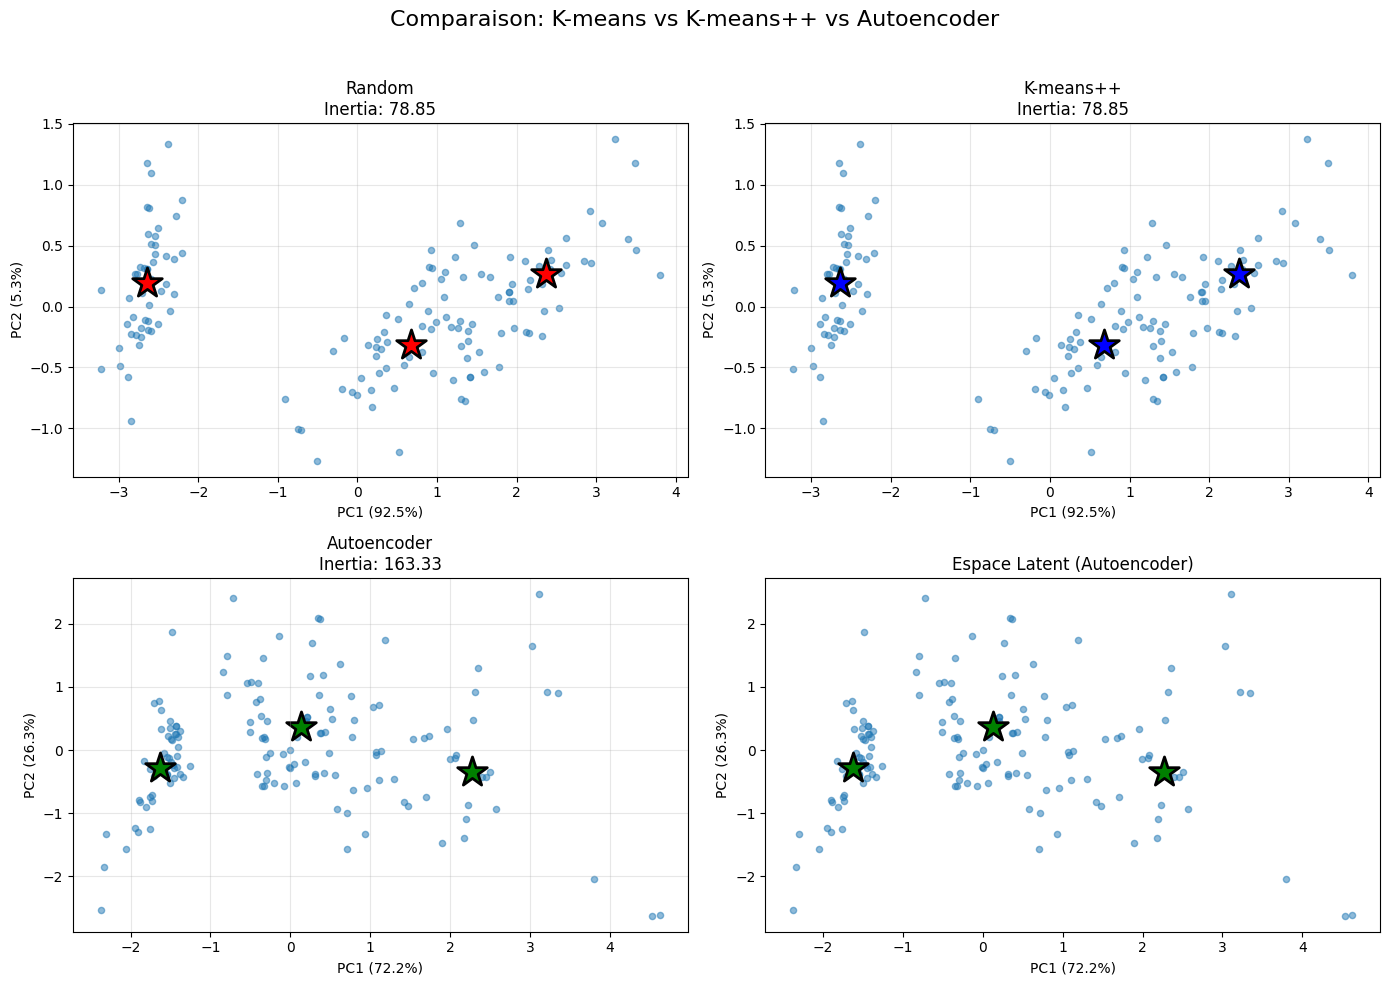


✅ Demo complétée!


In [ ]:
if __name__ == "__main__":
    print("[v0] Deep Embedded Clustering Demo")
    print("="*80)
    
    # === Test 1: Données synthétiques ===
    print("\n[TEST 1] Données synthétiques (300 points, 4 clusters)")
    X_synth, y_synth = make_blobs(n_samples=300, n_features=10, 
                                  centers=4, random_state=42, cluster_std=0.8)
    
    results_synth, Z_synth = compare_methods(X_synth, n_clusters=4)
    visualize_results(X_synth, results_synth, Z_synth)
    plot_convergence_and_times(results_synth, save_path="synth_convergence_times.png")
    # === Test 2: Iris Dataset ===
    print("\n\n[TEST 2] Iris Dataset (150 points, 4 features, 3 clusters)")
    iris = load_iris()
    X_iris = iris.data
    
    results_iris, Z_iris = compare_methods(X_iris, n_clusters=3)
    visualize_results(X_iris, results_iris, Z_iris)
    plot_convergence_and_times(results_iris, save_path="iris_convergence_times.png")
    
    print("\n" + "="*80)
    print("✅ Demo complétée!")
    print("="*80)

[v0] Deep Embedded Clustering Demo

[TEST 1] Données synthétiques (300 points, 4 clusters)

COMPARAISON: Random vs K-means++ vs Autoencoder+KMeans

[1] K-means Random (baseline mauvais):
     Inertia: 3782.92
     Silhouette: 0.8485
     Davies-Bouldin: 0.2148

[2] K-means++ (baseline bon):
     Inertia: 3782.92
     Silhouette: 0.8485
     Davies-Bouldin: 0.2148

[3] Autoencoder + K-means (NOUVEAU):

[v0] Entraînement autoencoder:
     Input: 20 features → Latent: 3 dims
     Epoch  20/100: Loss = 0.102661
     Epoch  40/100: Loss = 0.085360
     Epoch  60/100: Loss = 0.072965
     Epoch  80/100: Loss = 0.072005
     Epoch 100/100: Loss = 0.068729

[v0] Espace latent:
     Forme: (300, 3)
     Densité: 300 points dans 3D

[v0] Centroïdes trouvés dans l'espace latent:
     Forme: (4, 3)
     Inertie latent: 6.81
     Inertia: 6.81
     Silhouette: 0.9156
     Davies-Bouldin: 0.1156

RÉSUMÉ:

Random:
  Inertia:         3782.92
  Silhouette:       0.8485
  Davies-Bouldin:   0.2148

K-mea

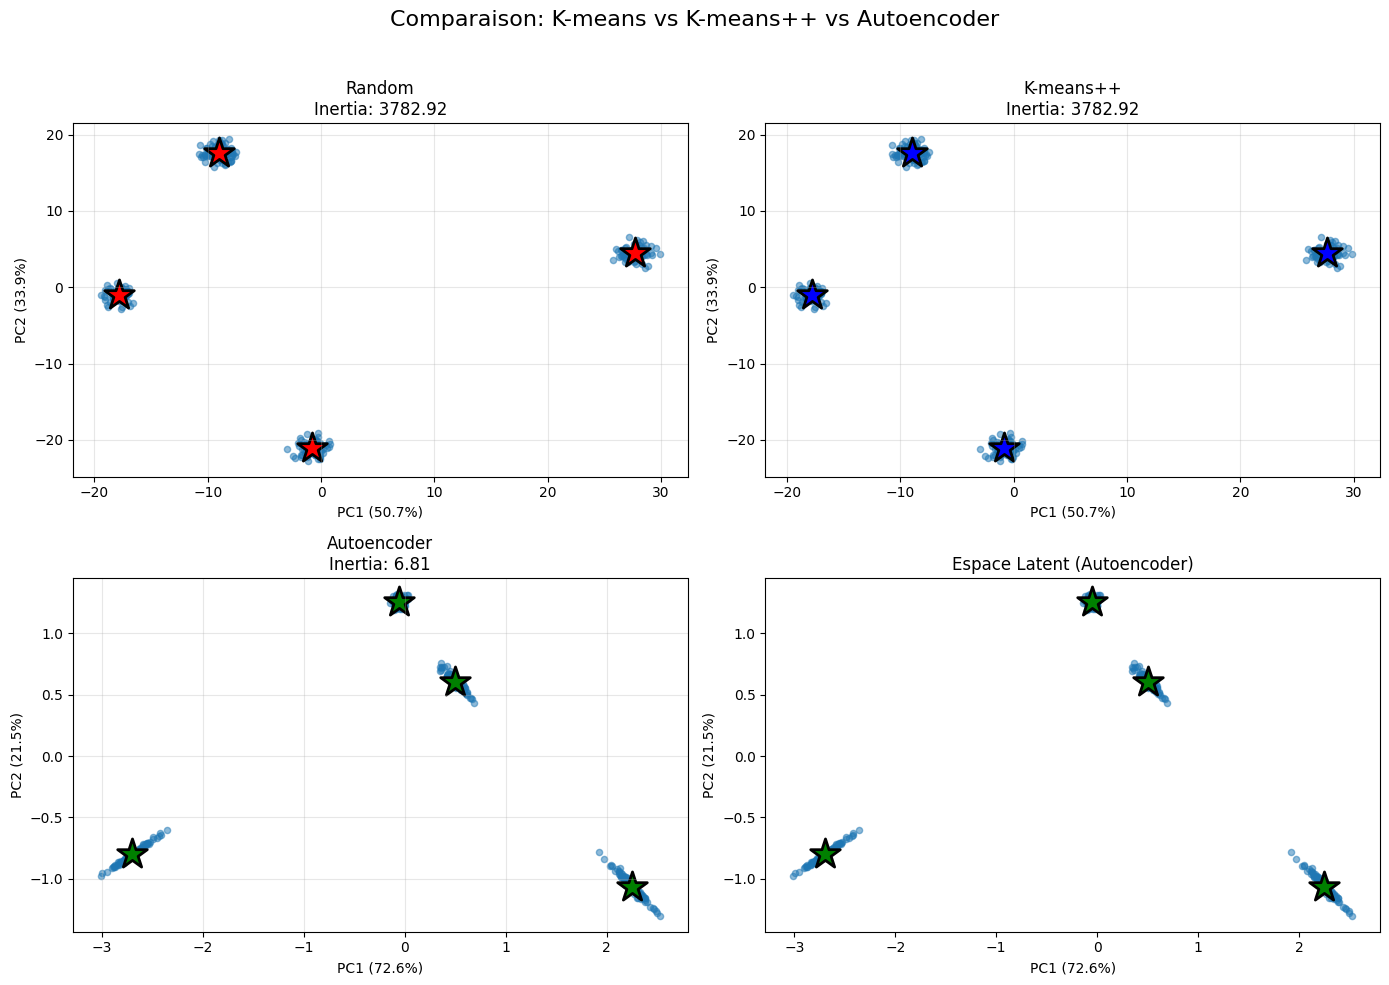



[TEST 2] Iris Dataset (150 points, 4 features, 3 clusters)

COMPARAISON: Random vs K-means++ vs Autoencoder+KMeans

[1] K-means Random (baseline mauvais):
     Inertia: 78.85
     Silhouette: 0.5528
     Davies-Bouldin: 0.6620

[2] K-means++ (baseline bon):
     Inertia: 78.85
     Silhouette: 0.5528
     Davies-Bouldin: 0.6620

[3] Autoencoder + K-means (NOUVEAU):

[v0] Entraînement autoencoder:
     Input: 4 features → Latent: 3 dims
     Epoch  20/100: Loss = 0.278112
     Epoch  40/100: Loss = 0.132758
     Epoch  60/100: Loss = 0.113175
     Epoch  80/100: Loss = 0.094880
     Epoch 100/100: Loss = 0.083324

[v0] Espace latent:
     Forme: (150, 3)
     Densité: 150 points dans 3D

[v0] Centroïdes trouvés dans l'espace latent:
     Forme: (3, 3)
     Inertie latent: 200.43
     Inertia: 200.43
     Silhouette: 0.4953
     Davies-Bouldin: 0.8150

RÉSUMÉ:

Random:
  Inertia:           78.85
  Silhouette:       0.5528
  Davies-Bouldin:   0.6620

K-means++:
  Inertia:           78.8

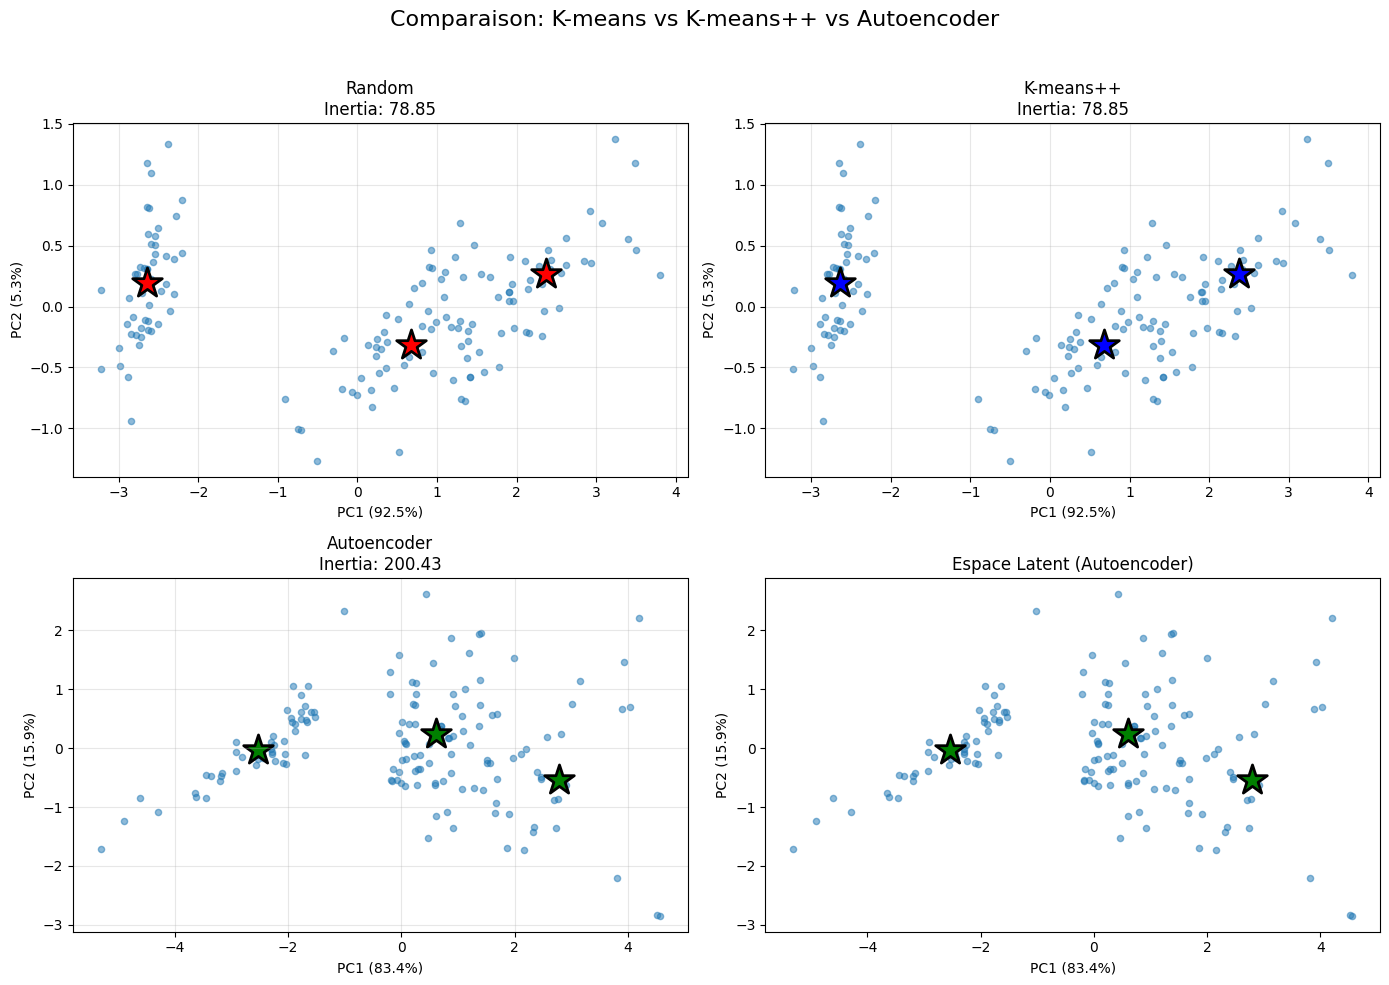


✅ Demo complétée!


In [ ]:
if __name__ == "__main__":
    print("Deep Embedded Clustering Demo")
    print("="*80)
    
    # === Test 1: Données synthétiques ===
    print("\n[TEST 1] Données synthétiques (300 points, 4 clusters)")
    X_synth, y_synth = make_blobs(n_samples=300, n_features=20, 
                                  centers=4, random_state=42, cluster_std=0.8)
    
    results_synth, Z_synth = compare_methods(X_synth, n_clusters=4)
    visualize_results(X_synth, results_synth, Z_synth)
    
    # === Test 2: Iris Dataset ===
    print("\n\n[TEST 2] Iris Dataset (150 points, 4 features, 3 clusters)")
    iris = load_iris()
    X_iris = iris.data
    
    results_iris, Z_iris = compare_methods(X_iris, n_clusters=3)
    visualize_results(X_iris, results_iris, Z_iris)
    
    print("\n" + "="*80)
    print("✅ Demo complétée!")
    print("="*80)